## 공공 자전거 장기 연체 예측
- 이전 실습에서 정제한 대여 기록으로 **100분 초과 장기 연체** 를 예측하는 분류 모델
- **어떤 오류를 줄일 것인가** 를 비용으로 판단

> **담당자가 덧붙인 말**\
> "정확도가 84% 나왔는데, 정작 연체될 자전거는 한 건도 예측하지 못했습니다. 왜 그런 걸까요?"

|파일|내용|
|:--:|:--:|
|data/clean_rentals.csv|(이전 실습 최종 결과물) 정제된 대여 기록|
|data/users.csv|이용자 마스터|

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from _style import setup
from _ml import (load_rentals, load_users, add_features, merge_users, time_split, encode,
                 SEED, TARGET, LEAK_COLS, NUM_FEATURES, CAT_FEATURES)

setup()
pd.set_option("display.width", 130)
pd.set_option("display.max_columns", 20)

print("준비 완료")

준비 완료


---
## [STEP 1] 파생변수 생성 및 정답지(Target) 만들기

### 요구사항

`clean_rentals.csv`를 불러온 뒤 아래 파생변수들을 만드세요.

1. **대여 시간(분)**: `duration_min = return_time - rent_time` 의 분 단위 계산
2. **`is_overdue_100m` (예측 대상)**: 대여 시간(`duration_min`)이 100분(1시간 40분)을 초과하면 `1`, 아니면 `0`
3. 대여 시점(`rent_time`) 기준 **시간대(hour)** 와 **요일** 추출
- 전체 행 수와 **`is_overdue_100m` 의 비율**을 확인하세요.
- **"전부 정상(미반납 아님)"이라고 답할 때의 정확도**를 계산하세요. 담당자가 말한 "정확도 84%"의 정체가 바로 이것입니다.

In [2]:
df = load_rentals()
df = add_features(df)

print(f"전체 행 수 : {len(df):,}")
print(f"대여 시간 범위 : {df['duration_min'].min():.0f} ~ {df['duration_min'].max():.0f} 분")
print()

df[["rent_time", "return_time", "duration_min", TARGET, "hour", "dayofweek"]].head()

전체 행 수 : 13,501
대여 시간 범위 : 5 ~ 120 분



,rent_time,return_time,duration_min,is_overdue_100m,hour,dayofweek
0,2022-04-18 20:28:00,2022-04-18 20:44:00,16.0,0,20,0
1,2022-05-19 09:53:00,2022-05-19 11:08:00,75.0,0,9,3
2,2022-09-07 16:20:00,2022-09-07 18:04:00,104.0,1,16,2
3,2022-10-11 06:39:00,2022-10-11 07:18:00,39.0,0,6,1
4,2022-07-11 10:15:00,2022-07-11 10:53:00,38.0,0,10,0


In [3]:
# 정답 비율
cnt = df[TARGET].value_counts()

print(f"{'구분':<12}{'건수':>8}{'비율':>10}")
print("-" * 30)
print(f"{'0 (정상)':<12}{cnt.loc[0]:>8,}{cnt.loc[0] / len(df):>10.2%}")
print(f"{'1 (장기연체)':<10}{cnt.loc[1]:>8,}{cnt.loc[1] / len(df):>10.2%}")
print()

# "전부 정상(0)" 이라고 답할 때의 정확도
all_normal = np.zeros(len(df), dtype=int)       # 전부 0 인 예측
acc_all_normal = (all_normal == df[TARGET]).mean()

print(f"'전부 정상' 정확도 : {acc_all_normal:.2%}")

구분                건수        비율
------------------------------
0 (정상)        11,136    82.48%
1 (장기연체)     2,365    17.52%

'전부 정상' 정확도 : 82.48%


> **"정확도 84%" 의 정체**
>
> 장기 연체는 전체의 약 17.5% -> 정상이 약 82.5% 인 **불균형 데이터**\
> 모델 없이 "전부 정상" 이라고만 답해도 정확도가 **82.48%**\
> (문제는 "약 13,500행" 기준이라 정제 방식에 따라 수치가 조금 다를 수 있음)

**정확도가 높다 ≠ 연체를 잘 잡는다**\
연체를 한 건도 못 맞혀도, 정상 비율만큼 정확도가 나옴

---
## [STEP 2] 결합 및 사용자 파생변수
### 요구사항

- 대여 기록에 `users.csv` 를 결합하세요. (`how` 와 `validate` 명시)
- **결합 전후 행 수를 비교**하여 중복이 발생하지 않았는지 확인하세요.
- `join_date` 와 `rent_time` 을 활용해, 대여 시점 기준 **유저의 가입 기간(일)** 파생변수를 만드세요.

In [4]:
users = load_users()

n_before = len(df)

# 가입 기간 보정 전 상태를 확인하기 위해 음수 개수 먼저 계산
check = df.merge(users, on="user_id", how="left", validate="many_to_one")
raw_days = (check["rent_time"] - check["join_date"]).dt.days

df = merge_users(df, users)

print(f"결합 전후 행 수 : {n_before:,} -> {len(df):,} ({len(df) - n_before:+,})")
print(f"매칭 실패 (membership_type 결측) : {df['membership_type'].isna().sum()} 건")
print()
print(f"가입 기간 < 0 (가입일이 대여일보다 늦음) : {(raw_days < 0).sum():,} 행 ({(raw_days < 0).mean():.1%})")
print()
print(df["join_days"].describe().round(1))

결합 전후 행 수 : 13,501 -> 13,501 (+0)
매칭 실패 (membership_type 결측) : 0 건

가입 기간 < 0 (가입일이 대여일보다 늦음) : 6,160 행 (45.6%)

count    13501.0
mean       159.5
std        196.7
min          0.0
25%          0.0
50%         42.0
75%        312.0
max        720.0
Name: join_days, dtype: float64


---
## [STEP 3] 데이터 누수 탐지

**이 단계가 이 문제의 첫 번째 관문입니다.**

지금 데이터프레임 안에는 **모델에 넣으면 안 되는 컬럼**이 섞여 있습니다.
학습 시점(대여 시점)에는 절대 알 수 없는 정보, 즉 **결과가 나온 뒤(반납 시점)에야 확정되는 값**들입니다.

### 요구사항

1. 각 컬럼들을 살펴보고 `is_overdue_100m` 와 직결되어 있는 누수(Leakage) 컬럼을 모두 찾아내세요.
2. 의심스러운 컬럼들을 찾고, **왜 학습에 쓰면 안 되는지** 설명하세요.


💡
**판단 기준**

“이 값은 **언제** 확정되는가?”를 기준으로 판단해보세요.

우리는 사용자가 자전거를 **빌려가는 순간(`rent_time`)**에 미반납 여부를 예측해야 합니다. 그 시점에 알 수 없는 값(ex. 주행 거리)이 포함되어 있다면 모두 누수로 판단하면 됩니다.


**리포트에 반드시 쓸 것**

- 제거한 컬럼 이름들 (최소 3개 이상)
- 그 값이 **언제** 확정되는지
- 그대로 학습하면 실제 운영에서 무슨 일이 벌어지는지

In [5]:
print(f"누수 컬럼 : {LEAK_COLS}")
print()

# 정답(0/1) 별 평균 -> 연체(1) 그룹에서 값이 확연히 다르면 정답과 직결된 정보
print(df.groupby(TARGET)[["duration_min", "distance_km", "fee"]].mean().round(1))
print()

# duration_min 은 100 을 기준으로 완벽하게 나뉨
print(df.groupby(TARGET)["duration_min"].agg(["min", "max"]))

누수 컬럼 : ['return_time', 'duration_min', 'distance_km', 'fee']

                 duration_min  distance_km     fee
is_overdue_100m                                   
0                        54.9          7.6  1304.8
1                       110.4          7.8  1881.1

                   min    max
is_overdue_100m              
0                  5.0  100.0
1                101.0  120.0


**제거한 컬럼** : `return_time`, `duration_min`, `distance_km`, `fee`
- 네 컬럼 모두 **반납이 끝난 뒤에야** 확정되는 값
- `duration_min` : 정답을 만든 값 그 자체 (정상 5 ~ 100분 / 연체 101 ~ 120분)
- `return_time` : rent_time 과 빼기만 하면 duration_min 이 나옴
- `fee` : 오래 탈수록 커짐 (평균 정상 1,305원 / 연체 1,881원)
- `distance_km` : 주행이 끝나야 알 수 있음

> **그대로 학습하면?**
>
> 테스트 점수는 거의 100% 로 나오지만, 실제로 대여하는 순간에는 이 값들이 존재하지 않음\
> 입력값이 없어서 모델을 쓸 수 없거나, 임의 값으로 채우면 예측이 엉망이 됨\
> => **답안지를 보고 시험을 푼 모델**

---
## [STEP 4] 학습, 테스트 분할

### 요구사항

- **시점(`rent_time`) 기준**으로 분할하세요. 상위 80% 날짜를 기준선으로 삼습니다.
- 범주형 변수(`payment_method`, `membership_type` 등)를 인코딩하세요.
- **테스트 세트의 열 구성을 학습 세트에 맞추세요.**

<aside>
⚠️

**랜덤 분할을 쓰면 안 됩니다.**

시계열 데이터에서 랜덤 분할을 쓰면, 미래의 패턴으로 과거를 예측하는 오류를 범하게 됩니다.

</aside>

In [6]:
train, test, cutoff = time_split(df)

y_train, y_test = train[TARGET], test[TARGET]

print(f" * 기준선   {cutoff}")
print(f" * 학습     {len(train):,} 행 ({train['rent_time'].min().date()} ~ {train['rent_time'].max().date()}) / 연체 비율 {y_train.mean():.2%}")
print(f" * 테스트   {len(test):,} 행 ({test['rent_time'].min().date()} ~ {test['rent_time'].max().date()}) / 연체 비율 {y_test.mean():.2%}")

 * 기준선   2022-10-20 16:21:00
 * 학습     10,801 행 (2022-01-01 ~ 2022-10-20) / 연체 비율 17.38%
 * 테스트   2,700 행 (2022-10-20 ~ 2022-12-31) / 연체 비율 18.07%


In [7]:
X_train, X_test = encode(train, test)

print(f"숫자형 피처 : {NUM_FEATURES}")
print(f"범주형 피처 : {CAT_FEATURES}")
print()
print(f"X_train : {X_train.shape} / X_test : {X_test.shape}")
print(f"열 구성 일치 : {X_train.columns.tolist() == X_test.columns.tolist()}")
print()
print(X_train.columns.tolist())

숫자형 피처 : ['hour', 'dayofweek', 'join_days']
범주형 피처 : ['membership_type', 'payment_method', 'bike_type', 'district']

X_train : (10801, 21) / X_test : (2700, 21)
열 구성 일치 : True

['hour', 'dayofweek', 'join_days', 'membership_type_BASIC', 'membership_type_PREMIUM', 'payment_method_APP', 'payment_method_CARD', 'payment_method_MEMBERSHIP', 'bike_type_일반', 'bike_type_전동', 'district_강남구', 'district_강동구', 'district_강북구', 'district_강서구', 'district_관악구', 'district_광진구', 'district_구로구', 'district_금천구', 'district_노원구', 'district_도봉구', 'district_미배치']


> **테스트 열 구성을 학습에 맞추는 이유**
>
> 학습과 테스트를 따로 `get_dummies` 하면 범주가 달라 열 구성이 달라질 수 있음\
> -> 학습에만 있는 열은 테스트에 0 으로 추가, 테스트에만 있는 열은 제외

---
## [STEP 5] 누수의 위력 확인

STEP 3에서 찾은 컬럼 중 하나(예: `fee` 또는 `duration_min`)를 **일부러 넣어서** 학습해 보세요.

### 요구사항

`RandomForestClassifier` 로 두 번 학습하고 비교하세요.

1. 누수 컬럼을 모두 **제거한** 피처
2. 누수 컬럼을 **포함한** 피처

정확도, 재현율, F1, AUC 를 나란히 놓고 비교합니다. 누수 컬럼이 포함되었을 때 모델 성능이 비정상적으로 완벽해지는지 확인하세요.

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# 학습 -> 예측 -> 평가
결과 = []

for label, extra in [("누수 제거", None), ("누수 포함 (duration_min)", ["duration_min"])]:
    Xtr, Xte = encode(train, test, extra)

    m = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=SEED, n_jobs=-1)
    m.fit(Xtr, y_train)                     # 학습

    pred = m.predict(Xte)                   # 예측 (결과)
    proba = m.predict_proba(Xte)[:, 1]      # 예측 (확률)

    결과.append({
        "구분": label,
        "정확도": accuracy_score(y_test, pred),
        "재현율": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0),
        "AUC": roc_auc_score(y_test, proba)
    })

print(pd.DataFrame(결과).round(4).to_string(index=False))

                  구분    정확도  재현율  F1    AUC
               누수 제거 0.8193  0.0 0.0 0.4901
누수 포함 (duration_min) 1.0000  1.0 1.0 1.0000


> **누수 포함 시 모든 지표가 1.0**
>
> 정답을 만든 값(duration_min)을 그대로 줬기 때문에 "100분 넘으면 1" 이라는 규칙만 외운 것\
> 대여 순간에는 duration_min 을 알 수 없으므로 **실제로는 쓸 수 없는 점수**

**누수를 의심해야 하는 경우**
- 성능이 기대보다 과하게 좋은 경우
- 특정 피처 하나의 중요도가 압도적으로 높을 경우

---
## [STEP 6] 모델 비교

누수를 완벽히 제거한 피처(대여 시점에 알 수 있는 정보만 남김)로 여러 모델을 학습하고 비교하세요.

### 요구사항

아래 다섯 가지를 학습하고 **정확도, 정밀도, 재현율, F1, AUC** 를 표로 정리하세요.

| 모델 | 비고 |
| --- | --- |
| `DummyClassifier` | 베이스라인 |
| `LogisticRegression` | 스케일링 필요 |
| `LogisticRegression(class_weight="balanced")` | - |
| `RandomForest` | 스케일링 불필요 |
| `RandomForest(class_weight="balanced")` | - |

### 확인 문항

1. `DummyClassifier` 와 `RandomForest` 의 정확도가 거의 똑같습니다. 무슨 일이 일어난 걸까요?
2. 담당자가 말한 "정확도 84%인데 연체를 못 잡는다"가 어느 상황에 해당하나요?
3. `class_weight="balanced"` 를 넣으면 정확도가 **떨어집니다.** 그런데도 왜 불균형 데이터에서는 이 옵션을 써야 하나요?

In [9]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# 스케일링이 필요한 모델은 Pipeline 으로 묶어주기
def with_scaler(model):
    return Pipeline(
        [
            ("sc", StandardScaler()),
            ("m", model)
        ]
    )

models = {
    "DummyClassifier": DummyClassifier(strategy="most_frequent"),
    "LogisticRegression": with_scaler(LogisticRegression(max_iter=1000, random_state=SEED)),
    "LogisticRegression(balanced)": with_scaler(LogisticRegression(max_iter=1000, random_state=SEED, class_weight="balanced")),
    "RandomForest": RandomForestClassifier(n_estimators=100, max_depth=6, random_state=SEED, n_jobs=-1),
    "RandomForest(balanced)": RandomForestClassifier(n_estimators=100, max_depth=6, random_state=SEED, n_jobs=-1, class_weight="balanced")
}

rows = []

for name, m in models.items():
    m.fit(X_train, y_train)                     # 학습

    pred = m.predict(X_test)                    # 예측 (결과)
    proba = m.predict_proba(X_test)[:, 1]       # 예측 (확률)

    rows.append({
        "모델": name,
        "정확도": accuracy_score(y_test, pred),
        "정밀도": precision_score(y_test, pred, zero_division=0),
        "재현율": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0),
        "AUC": roc_auc_score(y_test, proba),
        "연체 예측 건수": pred.sum()
    })

result = pd.DataFrame(rows)
print(result.round(4).to_string(index=False))
print()
print(f"테스트 실제 연체 : {y_test.sum()} 건 / {len(y_test):,} 건")

                          모델    정확도    정밀도    재현율     F1    AUC  연체 예측 건수
             DummyClassifier 0.8193 0.0000 0.0000 0.0000 0.5000         0
          LogisticRegression 0.8193 0.0000 0.0000 0.0000 0.4814         0
LogisticRegression(balanced) 0.4667 0.1708 0.5061 0.2554 0.4817      1446
                RandomForest 0.8193 0.0000 0.0000 0.0000 0.4901         0
      RandomForest(balanced) 0.5470 0.1638 0.3668 0.2264 0.4878      1093

테스트 실제 연체 : 488 건 / 2,700 건


**1. DummyClassifier 와 RandomForest 의 정확도가 거의 똑같은 이유**
- 두 모델 모두 테스트 데이터를 **전부 정상(0)** 으로 예측 (연체 예측 0 건)
- 연체가 17% 뿐이라 RandomForest 의 연체 확률이 기본 임계값 0.5 를 넘는 경우가 없음
- 결국 다수 클래스만 답하는 Dummy 와 같아짐 -> 정확도 = 정상 비율 (약 82%)

**2. "정확도 84% 인데 연체를 못 잡는다" 에 해당하는 상황**
- `class_weight` 를 쓰지 않은 Dummy, LogisticRegression, RandomForest
- 정확도는 80% 대지만 **재현율 0** -> 실제 연체 중 한 건도 못 맞힘
- 불균형 데이터에서 정확도는 정상 비율만큼 공짜로 올라가는 지표

**3. class_weight="balanced" 를 쓰는 이유**
- 개수가 적은 연체(1) 에 가중치를 줘서, 연체를 틀리면 더 크게 벌점을 받도록 학습
- 모델이 연체를 예측하기 시작함 -> **재현율, F1 이 0 에서 올라감**
- 정상을 연체로 잘못 예측(FP) 하는 경우가 늘어서 정확도는 떨어짐
- 목적이 "정상 맞히기" 가 아니라 **"연체 잡기"** 이므로 재현율이 더 중요

> **모든 모델의 AUC 가 0.48 ~ 0.49**\
> AUC 0.5 = 무작위 수준
> 현재 피처(요일, 시간, 가입기간, 결제수단 등) 로는 연체와 정상을 구분하는 힘이 거의 없음

---
## [STEP 7] 혼동행렬과 지표

### 요구사항

`RandomForest(balanced)` 의 혼동행렬을 구하고 **TP, FN, FP, TN 을 각각 자전거 도메인 관점에서 해석**하세요.

### 확인 문항

이 문제에서 **FN(연체를 놓침) 과 FP(정상을 연체로 예측) 중 어느 쪽이 치명적인가요?** 근거와 함께 정리해주세요.

In [10]:
final_model = models["RandomForest(balanced)"]
pred = final_model.predict(X_test)

# 불리언 마스크 & 로 개수 세기
tp = ((pred == 1) & (y_test == 1)).sum()    # 연체 예측 + 실제 연체
fn = ((pred == 0) & (y_test == 1)).sum()    # 정상 예측 + 실제 연체  -> 놓침
fp = ((pred == 1) & (y_test == 0)).sum()    # 연체 예측 + 실제 정상  -> 헛경보
tn = ((pred == 0) & (y_test == 0)).sum()    # 정상 예측 + 실제 정상

cm = pd.DataFrame([[tn, fp], [fn, tp]],
                  index=["실제 정상(0)", "실제 연체(1)"],
                  columns=["예측 정상(0)", "예측 연체(1)"])

print("[혼동행렬] RandomForest(balanced) / 임계값 0.5")
print(cm)
print()
print(f"재현율 = TP / (TP + FN) = {tp} / {tp + fn} = {tp / (tp + fn):.4f}")
print(f"정밀도 = TP / (TP + FP) = {tp} / {tp + fp} = {tp / (tp + fp):.4f}")

[혼동행렬] RandomForest(balanced) / 임계값 0.5
          예측 정상(0)  예측 연체(1)
실제 정상(0)      1298       914
실제 연체(1)       309       179

재현율 = TP / (TP + FN) = 179 / 488 = 0.3668
정밀도 = TP / (TP + FP) = 179 / 1093 = 0.1638


In [11]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.81      0.59      0.68      2212
           1       0.16      0.37      0.23       488

    accuracy                           0.55      2700
   macro avg       0.49      0.48      0.45      2700
weighted avg       0.69      0.55      0.60      2700



|구분|의미 (자전거 도메인)|운영 결과|
|:--:|:--:|:--:|
|**TP**|장기 연체할 대여를 **미리 잡아냄**|독촉 알림 -> 방치·연체료 손실 예방|
|**FN**|장기 연체를 **놓침**|자전거 방치, 회수 인건비 + 미수납 연체료 (**건당 15,000원**)|
|**FP**|정상 이용자를 **괜히 의심**|불필요한 독촉 연락, 고객 불만 (**건당 2,000원**)|
|**TN**|정상을 정상으로 판단|조치 없음 (비용 0)|

**FN 과 FP 중 치명적인 쪽 : FN (연체를 놓침)**
- 건당 비용 FN 15,000원 vs FP 2,000원 -> **FN 이 7.5배**
- FP 는 문자 한 통·CS 응대로 끝나지만, FN 은 직접 회수하러 가야 하고 연체료도 받지 못함
- FP 를 어느 정도 감수하더라도 **FN 을 줄이는 방향 (재현율 우선)** 으로 임계값을 정해야 함

---
## [STEP 8] 비용 기반 임계값 선택

**이 단계가 이 문제의 핵심입니다.**

운영팀에서 예측 오류에 따른 비용(손실) 정보를 알려줬습니다.

| 상황 | 비용 | 설명 |
| --- | --- | --- |
| **FN** (장기 연체를 놓침) | **15,000원** | 방치 자전거 회수 인건비 및 미수납 연체료 손실 |
| **FP** (정상인데 엄한 사람 의심) | **2,000원** | 이용자에게 반납 독촉 전화/문자 발송 및 고객 불만 CS 리소스 |

In [12]:
COST_FN = 15_000
COST_FP = 2_000

proba = final_model.predict_proba(X_test)[:, 1]     # 연체(1) 일 확률

# 0.05 ~ 0.95, 0.05 간격
ths = np.round(np.arange(0.05, 0.96, 0.05), 2)

rows = []

for t in ths:
    pred_t = (proba >= t).astype(int)       # 확률이 임계값 이상이면 연체(1)

    tp_t = ((pred_t == 1) & (y_test == 1)).sum()
    fn_t = ((pred_t == 0) & (y_test == 1)).sum()
    fp_t = ((pred_t == 1) & (y_test == 0)).sum()

    rows.append({
        "임계값": t,
        "TP": tp_t,
        "FN": fn_t,
        "FP": fp_t,
        "재현율": recall_score(y_test, pred_t, zero_division=0),
        "정밀도": precision_score(y_test, pred_t, zero_division=0),
        "F1": f1_score(y_test, pred_t, zero_division=0),
        "총비용": fn_t * COST_FN + fp_t * COST_FP
    })

cost_df = pd.DataFrame(rows)
print(cost_df.round(4).to_string(index=False))

 임계값  TP  FN   FP    재현율    정밀도     F1     총비용
0.05 488   0 2212 1.0000 0.1807 0.3061 4424000
0.10 488   0 2212 1.0000 0.1807 0.3061 4424000
0.15 488   0 2212 1.0000 0.1807 0.3061 4424000
0.20 488   0 2212 1.0000 0.1807 0.3061 4424000
0.25 488   0 2212 1.0000 0.1807 0.3061 4424000
0.30 488   0 2212 1.0000 0.1807 0.3061 4424000
0.35 488   0 2211 1.0000 0.1808 0.3062 4422000
0.40 483   5 2198 0.9898 0.1802 0.3048 4471000
0.45 444  44 2023 0.9098 0.1800 0.3005 4706000
0.50 179 309  914 0.3668 0.1638 0.2264 6463000
0.55  13 475   81 0.0266 0.1383 0.0447 7287000
0.60   1 487    0 0.0020 1.0000 0.0041 7305000
0.65   0 488    0 0.0000 0.0000 0.0000 7320000
0.70   0 488    0 0.0000 0.0000 0.0000 7320000
0.75   0 488    0 0.0000 0.0000 0.0000 7320000
0.80   0 488    0 0.0000 0.0000 0.0000 7320000
0.85   0 488    0 0.0000 0.0000 0.0000 7320000
0.90   0 488    0 0.0000 0.0000 0.0000 7320000
0.95   0 488    0 0.0000 0.0000 0.0000 7320000


In [13]:
# 총비용이 최소인 위치 : np.argmin
#   iloc[위치] : 그 위치의 행
best = cost_df.iloc[np.argmin(cost_df["총비용"])]
best_f1 = cost_df.iloc[np.argmax(cost_df["F1"])]

# 아무 예측도 하지 않을 때 = 전부 정상 -> 실제 연체가 전부 FN
n_pos = y_test.sum()
n_neg = (y_test == 0).sum()
cost_none = n_pos * COST_FN

# 참고 : 모델 없이 전원에게 독촉 -> 실제 정상이 전부 FP
cost_all = n_neg * COST_FP

print(f"[총비용 최소]  임계값 {best['임계값']}  TP {best['TP']:.0f}  FN {best['FN']:.0f}  FP {best['FP']:.0f}  총비용 {best['총비용']:,.0f} 원")
print(f"[F1 최대]     임계값 {best_f1['임계값']}  F1 {best_f1['F1']:.4f}  총비용 {best_f1['총비용']:,.0f} 원")
print(f"[기본값 0.5]  총비용 {cost_df.loc[cost_df['임계값'] == 0.5, '총비용'].iloc[0]:,.0f} 원")
print()
print(f"[아무 예측도 안 함]  FN {n_pos} 건 x {COST_FN:,} = {cost_none:,} 원")
print(f"[최적 임계값 적용]   {best['총비용']:,.0f} 원")
print(f"  => 절감액 : {cost_none - best['총비용']:,.0f} 원 ({(cost_none - best['총비용']) / cost_none:.1%})")
print()
print(f"[참고] 모델 없이 전원 독촉 : FP {n_neg} 건 x {COST_FP:,} = {cost_all:,} 원")
print(f"[참고] 손익분기 확률 = FP 비용 / (FN 비용 + FP 비용) = {COST_FP / (COST_FN + COST_FP):.3f}")

[총비용 최소]  임계값 0.35  TP 488  FN 0  FP 2211  총비용 4,422,000 원
[F1 최대]     임계값 0.35  F1 0.3062  총비용 4,422,000 원
[기본값 0.5]  총비용 6,463,000 원

[아무 예측도 안 함]  FN 488 건 x 15,000 = 7,320,000 원
[최적 임계값 적용]   4,422,000 원
  => 절감액 : 2,898,000 원 (39.6%)

[참고] 모델 없이 전원 독촉 : FP 2212 건 x 2,000 = 4,424,000 원
[참고] 손익분기 확률 = FP 비용 / (FN 비용 + FP 비용) = 0.118


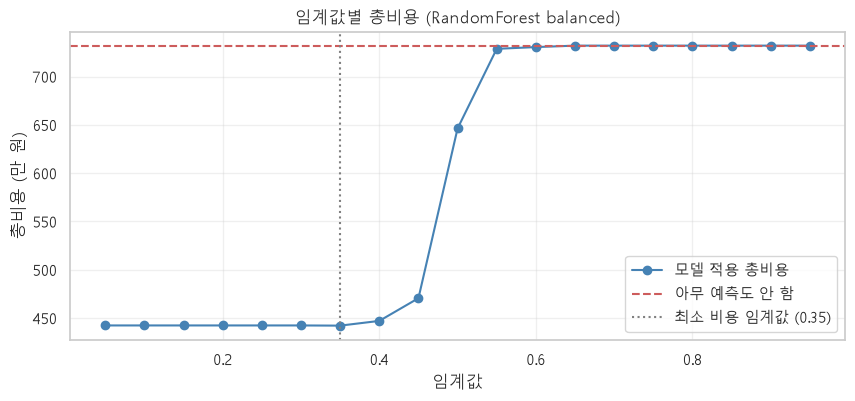

In [14]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(cost_df["임계값"], cost_df["총비용"] / 10_000, marker="o", color="steelblue", label="모델 적용 총비용")
ax.axhline(cost_none / 10_000, color="indianred", ls="--", label="아무 예측도 안 함")
ax.axvline(best["임계값"], color="gray", ls=":", label=f"최소 비용 임계값 ({best['임계값']})")

ax.set_xlabel("임계값")
ax.set_ylabel("총비용 (만 원)")
ax.set_title("임계값별 총비용 (RandomForest balanced)")
ax.legend()
ax.grid(alpha=0.3)

plt.show()

**결과**
- 총비용이 최소인 임계값은 **0.35** -> 테스트 2,700 건 중 2,699 건을 연체로 보고 독촉
- 아무 예측도 안 할 때 **7,320,000원** -> **4,422,000원** 으로 **2,898,000원 (39.6%) 절감**
- 기본 임계값 0.5 그대로 쓰면 **6,463,000원** -> 임계값만 바꿔도 2,041,000원 차이
- 이번 데이터는 F1 최대 임계값도 0.35 로 같지만, 거의 전원을 연체로 예측해서 재현율이 1.0 이 된 우연의 일치

> **정직한 해석**
>
> 손익분기 확률은 2,000 / (15,000 + 2,000) ≈ **0.118** -> 연체 확률이 12% 만 넘어도 독촉하는 편이 이득\
> 실제 연체율이 약 18% 라서 **누구에게나 독촉하는 것** 이 이미 이득인 상황\
> 최적 비용(4,422,000원) ≈ 모델 없이 전원 독촉(4,424,000원)\
> => 절감 효과는 모델의 예측력보다 **비용 구조상 공격적으로 독촉하는 정책** 에서 나온 것 (AUC ≈ 0.49)

---
## [STEP 9] 피처 중요도와 해석

### 요구사항

- 최종 모델의 피처 중요도를 구하고 상위 5개를 막대그래프로 그리세요.
- 운영팀에 보고한다고 가정하고 **"대여 시점에 어떤 정보(요일, 시간, 가입기간 등)를 주의 깊게 모니터링해야 하는가"** 를 3줄 이내로 정리하세요.

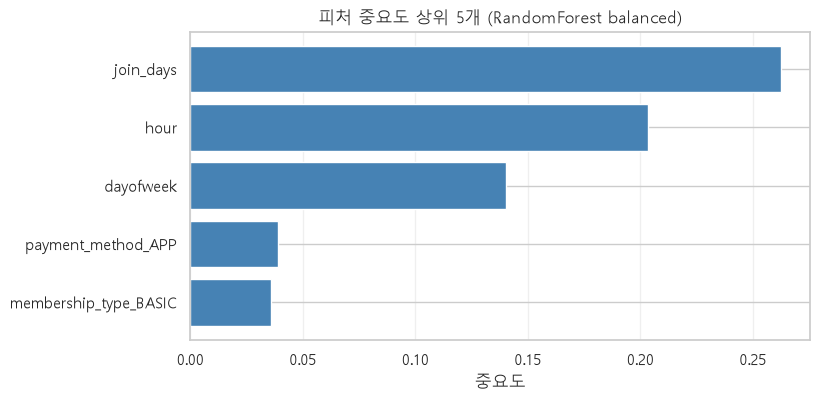

join_days                    0.2624
hour                         0.2032
dayofweek                    0.1405
payment_method_APP           0.0392
membership_type_BASIC        0.0359
membership_type_PREMIUM      0.0355
payment_method_MEMBERSHIP    0.0337
payment_method_CARD          0.0325
district_관악구                 0.0287
district_구로구                 0.0213
dtype: float64


In [15]:
imp = pd.Series(final_model.feature_importances_, index=X_train.columns).sort_values()
top5 = imp.tail(5)      # 오름차순 정렬의 마지막 5개 = 상위 5개 (barh 는 아래에서 위로 그려짐)

fig, ax = plt.subplots(figsize=(8, 4))

ax.barh(top5.index, top5.values, color="steelblue")

ax.set_xlabel("중요도")
ax.set_title("피처 중요도 상위 5개 (RandomForest balanced)")
ax.grid(alpha=0.3, axis="x")

plt.show()

print(imp.sort_values(ascending=False).head(10).round(4))

In [16]:
# 중요도 상위 피처의 실제 연체율 -> 운영팀 보고 근거

# 가입 기간 구간 : (시작, 끝, 이름) -> loc 마스크로 구간 이름 부여
JOIN_BINS = [
    (0, 1, "가입 당일(보정 포함)"),
    (1, 31, "1~30일"),
    (31, 91, "31~90일"),
    (91, 181, "91~180일"),
    (181, 366, "181~365일"),
    (366, 10000, "1년 초과"),
]

df["join_group"] = ""
for start, end, label in JOIN_BINS:
    mask = (df["join_days"] >= start) & (df["join_days"] < end)
    df.loc[mask, "join_group"] = label

order = [label for _, _, label in JOIN_BINS]

print("[가입 기간별 연체율]")
print(df.groupby("join_group")[TARGET].agg(["mean", "count"]).loc[order].round(3))
print()
print("[시간대별 연체율 상위 5]")
print(df.groupby("hour")[TARGET].mean().sort_values(ascending=False).head().round(3))
print()
print("[요일별 연체율] (0: 월 ~ 6: 일)")
print(df.groupby("dayofweek")[TARGET].mean().round(3))

[가입 기간별 연체율]
               mean  count
join_group                
가입 당일(보정 포함)  0.167   6170
1~30일         0.230    417
31~90일        0.166    728
91~180일       0.193   1189
181~365일      0.173   2347
1년 초과         0.182   2650

[시간대별 연체율 상위 5]
hour
6     0.201
18    0.192
20    0.185
7     0.184
19    0.179
Name: is_overdue_100m, dtype: float64

[요일별 연체율] (0: 월 ~ 6: 일)
dayofweek
0    0.169
1    0.179
2    0.172
3    0.172
4    0.187
5    0.179
6    0.168
Name: is_overdue_100m, dtype: float64


> **중요도는 인과관계를 뜻하진 않음**
> 숫자형 피처(가입기간, 시간대)는 나눌 지점이 많아 중요도가 높게 나오는 경향도 있음

**운영팀 보고 (3줄 요약)**
1. **가입 1개월 이내 신규 이용자** (연체율 약 23%, 평균 17.5%) 와 **이른 아침(6시)·퇴근 시간대(18~20시)** 대여를 우선 모니터링하세요.
2. 다만 현재 정보만으로는 연체를 골라내는 힘이 약해 (AUC ≈ 0.49), 비용상 **연체 확률 12% 이상이면 독촉하는 정책** 이 가장 유리합니다.
3. 예측력을 높이려면 이용자별 **과거 연체 이력**, 목적지·날씨 같은 **대여 시점 정보** 를 추가로 수집해야 합니다.